In [13]:
import torch
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
import random
import numpy as np
from PIL import Image, ImageFilter
from PIL import ImageDraw, ImageEnhance
import random


In [ ]:

class RandomGaussianNoise:
    def __init__(self, mean=0., std=0.01, p=0.3):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            return tensor + noise
        return tensor

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std}, p={self.p})"

class RandomGaussianBlur:
    def __init__(self, radius_min=0.1, radius_max=0.5):
        self.radius_min = radius_min
        self.radius_max = radius_max

    def __call__(self, img):
        radius = random.uniform(self.radius_min, self.radius_max)
        return img.filter(ImageFilter.GaussianBlur(radius))


class RandomShadow:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        shadow = Image.new('L', img.size, 0)
        draw = ImageDraw.Draw(shadow)

        for _ in range(random.randint(1, 3)):
            x1 = random.randint(0, img.width // 2)
            y1 = random.randint(0, img.height)
            x2 = random.randint(img.width // 2, img.width)
            y2 = random.randint(0, img.height)
            x0, x1_sorted = sorted([x1, x2])
            y0, y1_sorted = sorted([y1, y2])
            draw.ellipse([x0, y0, x1_sorted, y1_sorted], fill=random.randint(60, 120))

        shadow = shadow.filter(ImageFilter.GaussianBlur(radius=random.uniform(10, 30)))

        shadow = shadow.convert("RGB")
        shadow = ImageEnhance.Brightness(shadow).enhance(0.6)
        img = Image.blend(img, shadow, alpha=0.5)

        return img

class RandomBlackLines:
    def __init__(self, p=0.5, max_lines=5, max_thickness=5):
        self.p = p
        self.max_lines = max_lines
        self.max_thickness = max_thickness

    def __call__(self, img):
        if random.random() > self.p:
            return img

        draw = ImageDraw.Draw(img)
        num_lines = random.randint(1, self.max_lines)

        for _ in range(num_lines):
            x1 = random.randint(0, img.width)
            y1 = random.randint(0, img.height)
            x2 = random.randint(0, img.width)
            y2 = random.randint(0, img.height)
            thickness = random.randint(2, self.max_thickness)
            draw.line([x1, y1, x2, y2], fill=(0, 0, 0), width=thickness)

        return img

def mixup_data(x, y, alpha=0.4):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam



random_augmentations = [
    T.RandomRotation(30),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomPerspective(distortion_scale=0.5, p=1.0),
    RandomGaussianBlur(),
    RandomShadow(p=0.7),
    RandomBlackLines(p=0.6, max_lines=5, max_thickness=4),
]

class RandomSubsetTransform:
    def __init__(self, transforms, num_choices=2):
        self.transforms = transforms
        self.num_choices = num_choices

    def __call__(self, img):
        chosen_transforms = random.sample(self.transforms, self.num_choices)
        for t in chosen_transforms:
            img = t(img)
        return img

train_transform_balanced = T.Compose([
    T.RandomResizedCrop(150),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.2),
    RandomSubsetTransform(random_augmentations, num_choices=2),
    T.ToTensor(),
    RandomGaussianNoise(0., 0.02, p=0.3),
    T.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [35]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

dataset = ImageFolder(root='/Users/lunnet_1/Downloads/EPFL/MA2/Image_analysis/Final Project/dataset_project_iapr2025/train', transform=train_transform_balanced)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


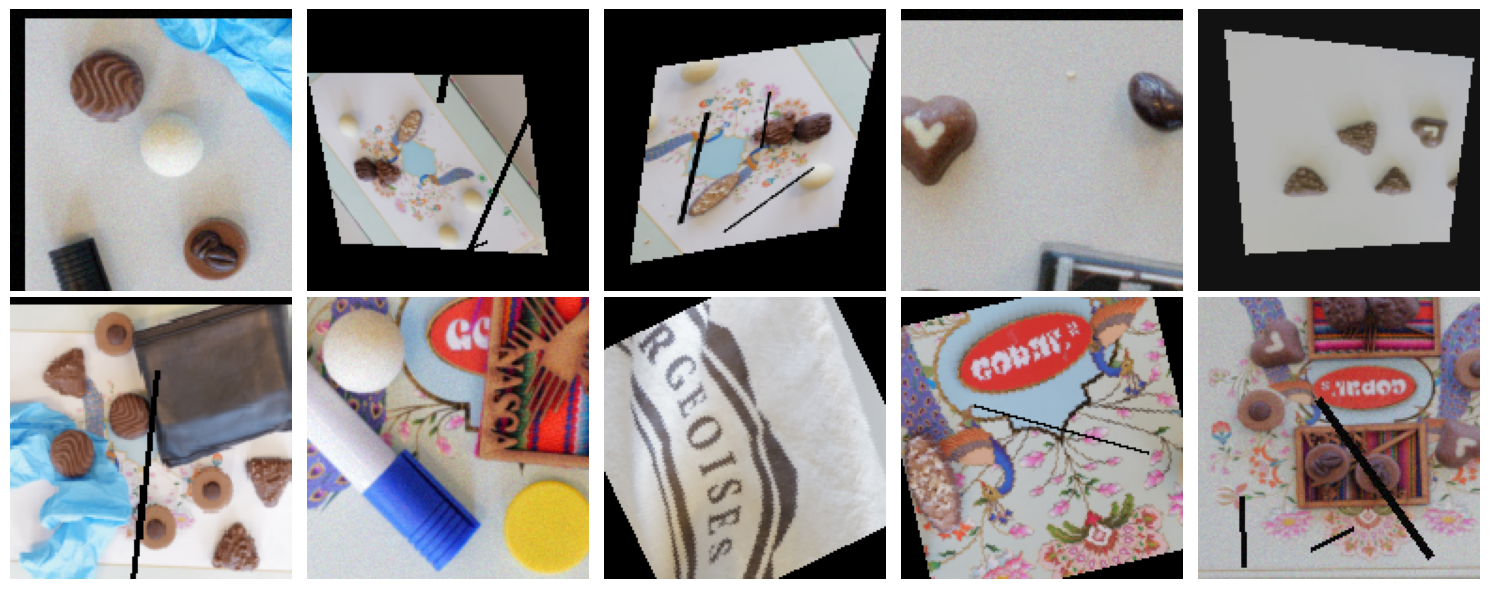

In [36]:
# Visualize some augmented images

import matplotlib.pyplot as plt
import torch

def imshow_grid(images, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        img = images[i].clone().detach().permute(1, 2, 0)
        img = img * 0.5 + 0.5  # unnormalize
        img = img.clamp(0, 1)
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

images = []
for _ in range(10):
    idx = torch.randint(len(dataset), (1,)).item()
    sample_img, _ = dataset[idx]
    images.append(sample_img)

imshow_grid(images, rows=2, cols=5)


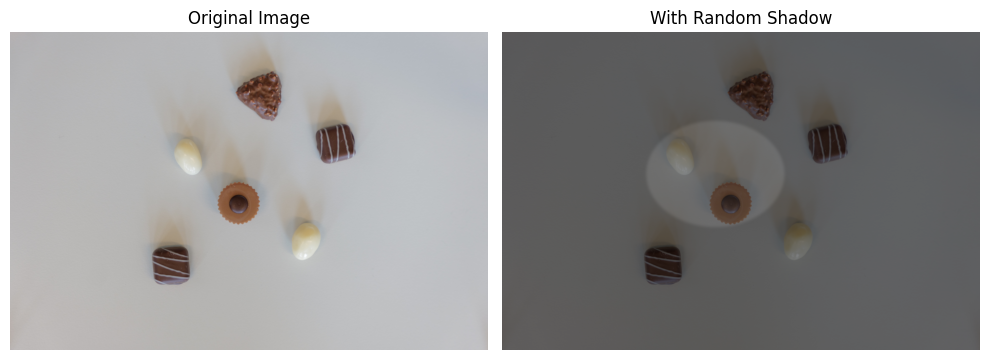

In [ ]:
# Visualize Random Shadow effect

import matplotlib.pyplot as plt
from PIL import Image

# Load a sample image (from your dataset or any local image)
original_img, _ = dataset[0]  # original image from dataset
original_pil = Image.open(dataset.samples[0][0])  # load as PIL for shadow demo

# Apply the RandomShadow transformation
shadow_transform = RandomShadow(p=1.0)  # force shadow for demo
shadow_img = shadow_transform(original_pil)

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(original_pil)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(shadow_img)
axs[1].set_title("With Random Shadow")
axs[1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Example snippet
import numpy as np
from PIL import Image

img = Image.open("chocolate.jpg").convert("RGB")
mask = Image.open("chocolate_mask.png").convert("L")  # grayscale mask

img_np = np.array(img)
mask_np = np.array(mask)

# Get bounding box
ys, xs = np.where(mask_np > 0)
ymin, ymax = ys.min(), ys.max()
xmin, xmax = xs.min(), xs.max()

# Extract chocolate
cropped_chocolate = img_np[ymin:ymax, xmin:xmax]
cropped_mask = mask_np[ymin:ymax, xmin:xmax]


from PIL import Image

# Convert to PIL
choc_crop_img = Image.fromarray(cropped_chocolate)
target_img = Image.open("target_background.jpg").convert("RGB")

# Random position
x_offset = np.random.randint(0, target_img.width - choc_crop_img.width)
y_offset = np.random.randint(0, target_img.height - choc_crop_img.height)

# Paste with mask
target_img.paste(choc_crop_img, (x_offset, y_offset), Image.fromarray(cropped_mask))


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class ChocolateAugDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        if self.transform:
            image = self.transform(image)
            # You might also want to transform the mask

        return image, mask


In [ ]:
dataset = ChocolateAugDataset(image_dir='/path/to/images', mask_dir='/path/to/masks', transform=train_transform_balanced)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
